In [22]:

# LICENSE PLATE DETECTION USING OPENCV
# TR: OpenCV Kullanarak Plaka Tespiti  


In [23]:

# Bu proje, OpenCV kütüphanesi kullanılarak bir araç plakasının
# görüntü üzerinde otomatik olarak tespit edilmesini sağlar.
#
# Amaç: Görüntü içerisindeki plaka benzeri bölgeyi tespit etmek ve
# dikdörtgen çerçeve ile işaretlemektir.
#
# ---------------------------------------------------------------
# 🔹 İşlem Adımları:
# ---------------------------------------------------------------
# 1. Görüntünün Okunması
#    - Görüntü hem renkli (BGR) hem de gri tonlamalı olarak okunur.
#
# 2. Gaussian Blur (Bulanıklaştırma)
#    - Gürültüyü azaltmak ve kenar tespitini daha kararlı hale getirmek için
#      görüntüye bulanıklaştırma (cv2.GaussianBlur) uygulanır.
#
# 3. Canny Edge Detection (Kenar Tespiti)
#    - Gri tonlamalı, bulanıklaştırılmış görüntüde kenarlar tespit edilir.
#    - Düşük ve yüksek eşik değerleri (örneğin 50 ve 150) kullanılarak
#      plaka sınırlarını temsil eden çizgiler belirlenir.
#
# 4. Kontur Bulma (Contour Detection)
#    - Kenar tespitinden elde edilen bölgelerdeki konturlar bulunur.
#    - Her kontur için dikdörtgen çevre (bounding box) hesaplanır.
#
# 5. Plaka Benzeri Bölgenin Filtrelenmesi
#    - Bulunan konturların oranı (genişlik / yükseklik) ve boyutları incelenir.
#    - Plaka oranına uygun (örneğin 2 < oran < 5) ve belirli alanda olan
#      konturlar seçilir.
#
# 6. Görselleştirme
#    - Uygun kontur bulunduğunda, bu bölge yeşil bir dikdörtgen ile işaretlenir.
#    - Sonuç görüntüsü OpenCV penceresinde gösterilir.
#
# ---------------------------------------------------------------
# 🔹 Kullanım Alanları:
# ---------------------------------------------------------------
# - Araç Plaka Tanıma Sistemleri (Automatic Number Plate Recognition - ANPR)
# - Trafik kontrol ve güvenlik sistemleri
# - Görüntü işleme ve bilgisayarla görme (Computer Vision) uygulamaları
#
# ---------------------------------------------------------------
# 🔹 Notlar:
# ---------------------------------------------------------------
# - cv2.Canny parametreleri (50,150) ve kontur filtreleme oranları
#   kullanılan görüntüye göre ayarlanabilir.
# - 'cv2.destroyAllWindows()' fonksiyonunun doğru yazıldığından emin olun.
# ===============================================================


In [24]:
import cv2  
# OpenCV kütüphanesini içe aktarır. 
# Görüntü okuma, yazma, işleme, kontur bulma, yüz tanıma gibi işlemler için kullanılır.

import numpy as np  
# NumPy kütüphanesini "np" takma adıyla içe aktarır.
# Sayısal işlemler, matris/dizi oluşturma ve matematiksel hesaplamalar için kullanılır.


In [ ]:
img_bgr = cv2.imread("./Hafta_8/plaka.jpg")
img_gray = cv2.imread("./Hafta_8/plaka.jpg",0)

# GaussianBlur fonksiyonu bir görüntüyü bulanıklaştırmaya yarar.
# Bu fonksiyon ilgili piksel kernel_size büyüklüğüne göre bu işlemde bi kernel_size değerini (5,5)
# komşu piksellerinin ağırlıklı ortalamasını alarak yeniden oluşturr.
# Fonksiyondaki sondaki 0 değeri ise sigmaX değerini  temsil eder.
# Biz bu değer 0 vererek asıl yumuşatma işleminin kernel_size ile işlenen değerden gelmesini sağlar.

blurring_img = cv2.GaussianBlur(img_gray, (5,5), 0)

# cv2.imshow("Original Image ", img_gray)
# cv2.imshow("Blurring Image ", blurring_img)
# cv2.waitKey(0)
# cv2.destoyAllWindows()

# Yumuşattığımız -bulanıklaştırdığımız görüntünün kenarları tespit edilir.
# Canny,  bir kenar bulma fonksiyonudur.
# İlk olarak, yumuşattığımız gri seviye görüntüyü parametre olarak verdik.
# Sonra, sırasıyla küçük-büyük eşik değeri veriyoruz.
# 50 ile 150 arasındaki piksellerin değeri kenar olabilir de olmayabilir de . 
# Ancak, 150 den büyük piksel değerleri kesinlikle kenar olarak kabul edilecek.
# 50 den küçük piksel değerleri de kabul edilmeyecek.

kenar = cv2.Canny(blurring_img, 50, 150)

# cv2.imshow("Original Image ", img_gray)
#cv2.imshow("Blurring Image ", blurring_img)
#cv2.imshow("Edge Detected Image ", kenar)
#cv2.waitKey(0)
#cv2.destoyAllWindows()

# Sıra geldi, kenarları tespit edilen görüntünün konturlarını bulmaya

konturlar, _ = cv2.findContours(kenar, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Elimizdeki yüm konturların tutulduğu konturlar isimli listenin içerisine girdik.
# Kontur ismini verdiğimiz geçic değişken ile her bir kontura eriştik.

for kontur in konturlar:
    # Görüntünün  sol üst tarafında (başlangıç (0,0) noktasından )
    # sağ alt tarafına kadar yani bitiş noktasına gitmek için 
    # x, y kordinaat bilgisi , w = genişlik (piksel sayısı), h = yükseklik(piksel sayısı)
    x, y, w, h = cv2.boundingRect(kontur)
    oran = w / float(h)
    alan = cv2.contourArea(kontur) 

    if 2<oran< 5 and 100<w<200 and 15<h<100 and alan>100:
        # eğer yukarıdaki şartları taşıyan bir kontur bulduysan 
        # onu yeşil renkle bir çerçeve içerisine al.
        cv2.rectangle(img_bgr, (x,y), (x+w, y+h), (0,255,0), 3)

cv2.imshow("Plaka Tespiti ", img_bgr)
cv2.waitKey(0)
cv2.destoyAllWindows()        

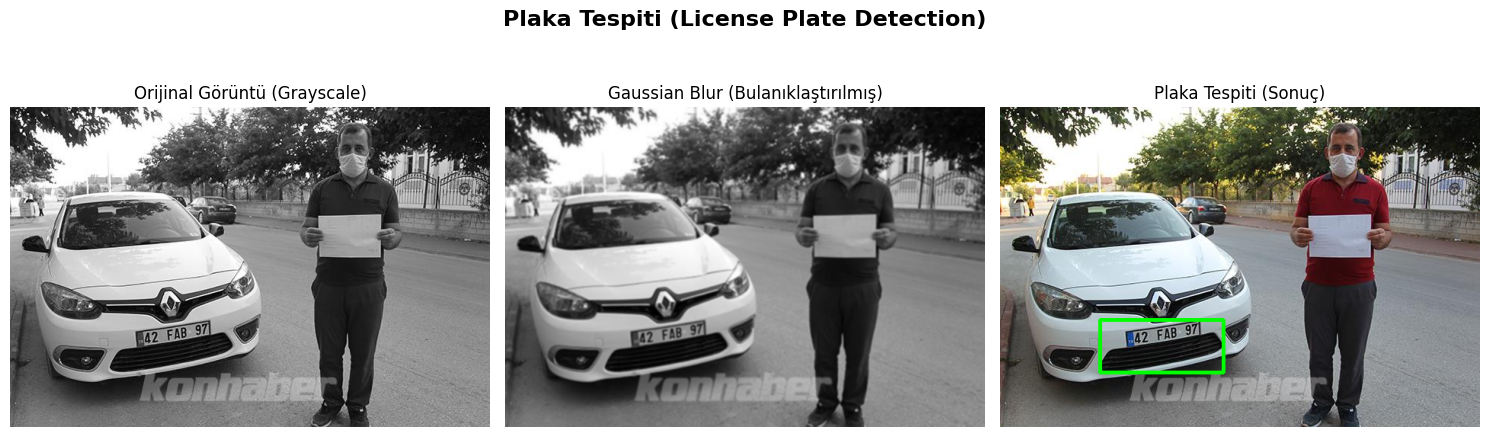

In [29]:
# ===============================================================
# OPENCV İLE PLAKA TESPİTİ (LICENSE PLATE DETECTION)
# ===============================================================


# Bu kod, OpenCV kullanarak bir araç plakasının görüntü üzerinde
# otomatik olarak tespit edilmesini sağlar.
# Gaussian Blur, Canny Edge Detection ve Kontur Analizi teknikleri kullanılır.
# ===============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Görüntüyü okuma (renkli ve gri tonlamalı)
img_bgr = cv2.imread("./Hafta_8/plaka.jpg")
img_gray = cv2.imread("./Hafta_8/plaka.jpg", 0)

# Gaussian Blur (bulanıklaştırma)
blurring_img = cv2.GaussianBlur(img_gray, (5, 5), 0)

# Canny Kenar Tespiti
kenar = cv2.Canny(blurring_img, 50, 150)

# Konturları bulma
konturlar, _ = cv2.findContours(kenar, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Konturları filtreleyerek olası plaka bölgesini tespit etme
for kontur in konturlar:
    x, y, w, h = cv2.boundingRect(kontur)
    oran = w / float(h)
    alan = cv2.contourArea(kontur)

    if 2 < oran < 5 and 100 < w < 200 and 15 < h < 100 and alan > 100:
        cv2.rectangle(img_bgr, (x, y), (x + w, y + h), (0, 255, 0), 3)

# ---------------------------------------------------------------
# Görselleri subplot ile yan yana çizdirme
# ---------------------------------------------------------------
plt.figure(figsize=(15, 5))
plt.suptitle("Plaka Tespiti (License Plate Detection)", fontsize=16, fontweight="bold")

# Orijinal gri tonlamalı görüntü
plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("Orijinal Görüntü (Grayscale)")
plt.axis("off")

# Bulanıklaştırılmış görüntü
plt.subplot(1, 3, 2)
plt.imshow(blurring_img, cmap='gray')
plt.title("Gaussian Blur (Bulanıklaştırılmış)")
plt.axis("off")

# Kenar tespit edilmiş ve plaka tespiti yapılmış görüntü
plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("Plaka Tespiti (Sonuç)")
plt.axis("off")

plt.tight_layout()
plt.show()


In [15]:
# ===============================================================
# ÖZET: 
# ===============================================================
#
# - Bu konu, bir görüntüdeki araç plakasını otomatik olarak tespit etmeyi kapsar.
# - OpenCV kütüphanesi kullanılarak kenar bulma (Canny) ve kontur analizi yapılır.
# - Görüntü hem renkli (BGR) hem de gri tonlamalı (Grayscale) olarak işlenir.
#
# ---------------------------------------------------------------
# 🔹 Adım Adım İşlem Özeti:
# ---------------------------------------------------------------
# 1. Görüntü Okuma:
#    - cv2.imread() ile renkli ve gri tonlamalı görüntü okunur.
#
# 2. Gaussian Blur (Bulanıklaştırma):
#    - Gürültüyü azaltmak için cv2.GaussianBlur() uygulanır.
#    - Bu, kenar tespitinde daha düzgün sonuçlar alınmasını sağlar.
#
# 3. Canny Edge Detection (Kenar Tespiti):
#    - cv2.Canny() ile kenarlar tespit edilir.
#    - 50 ve 150 gibi alt ve üst eşik değerleri kullanılır.
#
# 4. Kontur Bulma:
#    - cv2.findContours() ile kenarlardan oluşan konturlar bulunur.
#    - Konturlar, olası plaka bölgelerini temsil eder.
#
# 5. Plaka Filtreleme:
#    - Her konturun genişlik-yükseklik oranı (w/h) hesaplanır.
#    - Plaka formuna benzer oranlar (örneğin 2 < oran < 5) ve alan büyüklükleri
#      (örneğin w:100–200, h:15–100) filtrelenerek plaka bölgesi seçilir.
#
# 6. Görsel İşaretleme:
#    - Uygun kontur bulunduğunda cv2.rectangle() ile yeşil bir dikdörtgen çizilir.
#    - Sonuç görüntüsü cv2.imshow() ile ekranda gösterilir.
#
# ---------------------------------------------------------------
# 🔹 Kullanım Alanları:
# ---------------------------------------------------------------
# - Araç plaka tanıma sistemleri (ANPR)
# - Trafik izleme ve güvenlik uygulamaları
# - Bilgisayarla görme (Computer Vision) projeleri
# - Görüntü işleme ve nesne tespiti eğitim çalışmaları
#
# ---------------------------------------------------------------
# 🔹 Notlar:
# ---------------------------------------------------------------
# - Canny ve kontur parametreleri, kullanılan görüntüye göre ayarlanabilir.
# - cv2.destroyAllWindows() → tüm OpenCV pencerelerini kapatır.
# ===============================================================
